# Combined Dist 3 Analysis

This notebook keeps the `analysis-dist3.ipynb` workflow for the dist 3 dataset and extends the trust / interaction analysis sections with conditions `1`, `2`, `3`, and `9` from `Experiment1/data/first9`.


In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)

## 1. Data Loading and Preprocessing

In [2]:
DATA_DIR = Path("./data/dist 3/data")
CSV_PATTERN = "user_*.csv"


def extract_condition_number(condition_id):
    if pd.isna(condition_id):
        return np.nan

    for part in str(condition_id).split("_"):
        if part.isdigit():
            return int(part)

    return np.nan


def load_participant_data(file_path):
    df = pd.read_csv(file_path)
    df["source_file"] = file_path.name

    if "participant_id" not in df.columns or df["participant_id"].isna().all():
        participant_id = file_path.stem.split("_")[1]
        df["participant_id"] = participant_id

    if "condition_id" in df.columns:
        df["condition_id"] = df["condition_id"].fillna("unknown")
        df["condition_number"] = df["condition_id"].apply(extract_condition_number)
    else:
        df["condition_id"] = "unknown"
        df["condition_number"] = np.nan

    return df


csv_files = sorted(DATA_DIR.glob(CSV_PATTERN))
print(f"Using data directory: {DATA_DIR.resolve()}")
print(f"Found {len(csv_files)} participant CSV files")
print("Sample files:")
for file_path in csv_files[:10]:
    print(f"  - {file_path.name}")
if len(csv_files) > 10:
    print(f"  ... and {len(csv_files) - 10} more")

all_data = [load_participant_data(file_path) for file_path in csv_files]
combined_data = pd.concat(all_data, ignore_index=True)

before_participants = combined_data["participant_id"].nunique(dropna=True)
combined_data = combined_data[combined_data["participant_id"].notna()].copy()
combined_data = combined_data[~combined_data["participant_id"].astype(str).str.lower().eq("test")].copy()
after_participants = combined_data["participant_id"].nunique(dropna=True)

print()
print(f"Combined dataset shape: {combined_data.shape}")
print(f"Participants: {before_participants} -> {after_participants}")

Using data directory: /Users/songwen/Documents/Code Lab/Interact4Trust/Experiment1/data/dist 3/data
Found 104 participant CSV files
Sample files:
  - user_5015806700019318_2026-03-01T18-22-49-132.csv
  - user_50757123719421_2026-03-01T18-25-52-980.csv
  - user_50768174490167699_2026-03-01T18-23-55-407.csv
  - user_507846166510_2026-03-01T18-10-25-544.csv
  - user_512801430018385_2026-03-01T18-33-28-144.csv
  - user_5151118148000161086_2026-03-01T18-13-24-532.csv
  - user_516959870014161_2026-03-01T18-14-29-602.csv
  - user_5308729263285729_2026-03-01T18-14-43-337.csv
  - user_530941067700010_2026-03-01T18-21-43-587.csv
  - user_5316175500018596_2026-03-01T18-17-25-554.csv
  ... and 94 more

Combined dataset shape: (2392, 61)
Participants: 104 -> 104


In [3]:
print("Column names:")
print(combined_data.columns.tolist())

print("\nTrial type counts:")
print(combined_data["trial_type"].value_counts(dropna=False).to_string())

condition_lookup = (
    combined_data.loc[combined_data["condition_number"].notna(), ["condition_number", "condition_name", "condition_id"]]
    .drop_duplicates()
    .sort_values("condition_number")
    .reset_index(drop=True)
)

print("\nConditions present in this dataset:")
display(condition_lookup)

Column names:
['city_a_estimate', 'city_b_estimate', 'click_events', 'comprehension_ease', 'condition', 'condition_id', 'condition_name', 'confidence_label', 'confidence_rating', 'data_trust', 'device_pixel_ratio', 'display_format', 'effective_screen_width_px', 'end_time', 'failed_audio', 'failed_images', 'failed_video', 'hover_events', 'interaction_log', 'internal_node_id', 'participant_id', 'percent_score', 'phase', 'phase1_complete', 'phase2_complete', 'predictions_shown', 'probability_estimate', 'question_order', 'response', 'responses', 'round', 'rt', 'rt_total', 'screen_height', 'screen_width', 'skeptical_rating', 'slider_moved', 'start_time', 'stimulus', 'success', 'time_elapsed', 'time_on_viz', 'timeout', 'total_interactions', 'total_questions', 'total_score', 'travel_choice', 'trial_index', 'trial_type', 'trust_composite', 'ui_scale_preset', 'usability_composite', 'usability_difficulty', 'view_history', 'visualization_interaction_requirement_bypass_reason', 'visualization_inte

,condition_number,condition_name,condition_id
0,0.0,Historical Only,condition_0_historical
1,4.0,Ensemble + Hover,condition_4_ensemble_hover
2,5.0,PI Plot + Hover,condition_5_pi_hover
3,6.0,PI → Ensemble,condition_6_pi_to_ensemble
4,18.0,Glitch Ensemble + Hover,condition_18_glitch_hover
5,19.0,Glitch PI Plot + Hover,condition_19_glitch_pi_hover
6,20.0,Glitch PI → Ensemble,condition_20_glitch_pi_to_ensemble


In [4]:
relevant_trial_types = [
    "prediction-task",
    "vis-literacy",
    "trust-survey",
    "personality-survey",
    "survey-text",
    "survey-multi-choice",
]

relevant_trials = combined_data[combined_data["trial_type"].isin(relevant_trial_types)].copy()
relevant_trials["interaction_freq"] = np.log1p(
    relevant_trials["interaction_log"].fillna("").astype(str).str.len()
)

prediction_data = relevant_trials[relevant_trials["trial_type"] == "prediction-task"].copy()
phase1_data = prediction_data[prediction_data["phase"] == 1].copy()
phase2_data = prediction_data[prediction_data["phase"] == 2].copy()

treatment_conditions = sorted(
    int(value)
    for value in phase2_data["condition_number"].dropna().unique()
    if int(value) != 0
)

print(f"Relevant trial rows: {len(relevant_trials)}")
print(f"Prediction rows: {len(prediction_data)}")
print(f"Phase 1 rows: {len(phase1_data)}")
print(f"Phase 2 rows: {len(phase2_data)}")
print(f"Treatment conditions: {treatment_conditions}")

Relevant trial rows: 936
Prediction rows: 208
Phase 1 rows: 104
Phase 2 rows: 104
Treatment conditions: [4, 5, 6, 18, 19, 20]


## 2. Basic Statistics Tables by Condition

In [5]:
def create_condition_response_table(data, response_columns):
    rows = []

    grouped = data.groupby(["condition_number", "condition_name"], dropna=False)
    for (condition_number, condition_name), group in grouped:
        row_label = f"{int(condition_number)} - {condition_name}" if pd.notna(condition_number) else str(condition_name)
        row = {"condition": row_label, "participants": group["participant_id"].nunique()}
        for col in response_columns:
            row[col] = group[col].dropna().tolist() if col in group.columns else []
        rows.append(row)

    return pd.DataFrame(rows).set_index("condition")


def summarize_prediction_metrics(data, response_columns):
    summary = (
        data.groupby(["condition_number", "condition_name"], dropna=False)
        .agg(
            participants=("participant_id", "nunique"),
            probability_mean=("probability_estimate", "mean"),
            probability_sd=("probability_estimate", "std"),
            confidence_mean=("confidence_rating", "mean"),
            confidence_sd=("confidence_rating", "std"),
            interaction_mean=("interaction_freq", "mean"),
            interaction_sd=("interaction_freq", "std"),
        )
        .round(2)
        .reset_index()
        .sort_values("condition_number")
    )

    available_columns = [col for col in response_columns if col in data.columns]
    count_summary = (
        data.groupby(["condition_number", "condition_name"], dropna=False)[available_columns]
        .count()
        .reset_index()
        .sort_values("condition_number")
    )

    return summary, count_summary


phase1_columns = ["probability_estimate", "confidence_rating", "travel_choice"]
phase2_columns = [
    "probability_estimate",
    "confidence_rating",
    "travel_choice",
    "data_trust",
    "skeptical_rating",
]

phase1_response_table = create_condition_response_table(phase1_data, phase1_columns)
phase2_response_table = create_condition_response_table(phase2_data, phase2_columns)
phase1_summary, phase1_counts = summarize_prediction_metrics(phase1_data, phase1_columns)
phase2_summary, phase2_counts = summarize_prediction_metrics(phase2_data, phase2_columns)

print("Phase 1 response lists")
display(phase1_response_table)
print("Phase 1 summary")
display(phase1_summary)
print("Phase 1 non-null counts")
display(phase1_counts)

print("Phase 2 response lists")
display(phase2_response_table)
print("Phase 2 summary")
display(phase2_summary)
print("Phase 2 non-null counts")
display(phase2_counts)

Phase 1 response lists


,participants,probability_estimate,confidence_rating,travel_choice
condition,,,,
0 - Historical Only,104,"[20.0, 10.0, 18.0, 9.0, 26.0, 66.0, 14.0, 10.0...","[5.0, 5.0, 4.0, 7.0, 3.0, 2.0, 5.0, 5.0, 5.0, ...","[No Preference, City A, City A, City A, City A..."


Phase 1 summary


,condition_number,condition_name,participants,probability_mean,probability_sd,confidence_mean,confidence_sd,interaction_mean,interaction_sd
0,0.0,Historical Only,104,22.34,24.31,4.53,1.36,9.78,3.75


Phase 1 non-null counts


...

,participants,probability_estimate,confidence_rating,travel_choice,data_trust,skeptical_rating
condition,,,,,,
4 - Ensemble + Hover,19,"[10.0, 4.0, 10.0, 7.0, 14.0, 25.0, 20.0, 10.0,...","[4.0, 6.0, 5.0, 6.0, 5.0, 5.0, 4.0, 5.0, 5.0, ...","[City A, City A, City A, City A, City A, City ...",[],[]
5 - PI Plot + Hover,17,"[28.0, 18.0, 0.0, 2.0, 30.0, 60.0, 8.0, 9.0, 1...","[5.0, 4.0, 6.0, 4.0, 6.0, 2.0, 5.0, 5.0, 1.0, ...","[City A, City A, City A, City A, City A, No Pr...",[],[]
6 - PI → Ensemble,16,"[5.0, 6.0, 50.0, 0.0, 4.0, 8.0, 100.0, 17.0, 7...","[5.0, 3.0, 4.0, 5.0, 5.0, 4.0, 6.0, 6.0, 5.0, ...","[City A, City A, City A, City A, City A, City ...",[],[]
18 - Glitch Ensemble + Hover,19,"[14.0, 0.0, 75.0, 13.0, 0.0, 16.0, 15.0, 30.0,...","[6.0, 5.0, 4.0, 3.0, 7.0, 6.0, 5.0, 2.0, 5.0, ...","[City A, City B, No Preference, No Preference,...",[],[]
19 - Glitch PI Plot + Hover,15,"[0.0, 5.0, 5.0, 30.0, 0.0, 26.0, 2.0, 90.0, 50...","[7.0, 6.0, 5.0, 5.0, 5.0, 4.0, 6.0, 2.0, 2.0, ...","[City A, City A, City A, City A, City A, City ...",[],[]
20 - Glitch PI → Ensemble,18,"[7.0, 88.0, 21.0, 80.0, 5.0, 10.0, 98.0, 95.0,...","[4.0, 4.0, 4.0, 1.0, 6.0, 6.0, 5.0, 3.0, 5.0, ...","[City A, City A, City A, No Preference, City A...",[],[]


Phase 2 summary


,condition_number,condition_name,participants,probability_mean,probability_sd,confidence_mean,confidence_sd,interaction_mean,interaction_sd
0,4.0,Ensemble + Hover,19,18.37,20.45,5.37,0.83,11.53,1.57
1,5.0,PI Plot + Hover,17,18.06,17.20,4.71,1.40,11.55,1.68
2,6.0,PI → Ensemble,16,26.62,30.66,4.75,1.06,11.99,1.17
3,18.0,Glitch Ensemble + Hover,19,15.95,16.74,5.26,1.33,11.92,1.12
4,19.0,Glitch PI Plot + Hover,15,21.40,28.88,5.07,1.53,11.69,0.79
5,20.0,Glitch PI → Ensemble,18,35.78,37.48,4.50,1.38,12.24,1.08


Phase 2 non-null counts


,condition_number,condition_name,probability_estimate,confidence_rating,travel_choice,data_trust,skeptical_rating
0,4.0,Ensemble + Hover,19,19,19,0,0
1,5.0,PI Plot + Hover,17,17,17,0,0
2,6.0,PI → Ensemble,16,16,16,0,0
3,18.0,Glitch Ensemble + Hover,19,19,19,0,0
4,19.0,Glitch PI Plot + Hover,15,15,15,0,0
5,20.0,Glitch PI → Ensemble,18,18,18,0,0


## 3. Phase 1 to Phase 2 Shift Visualizations

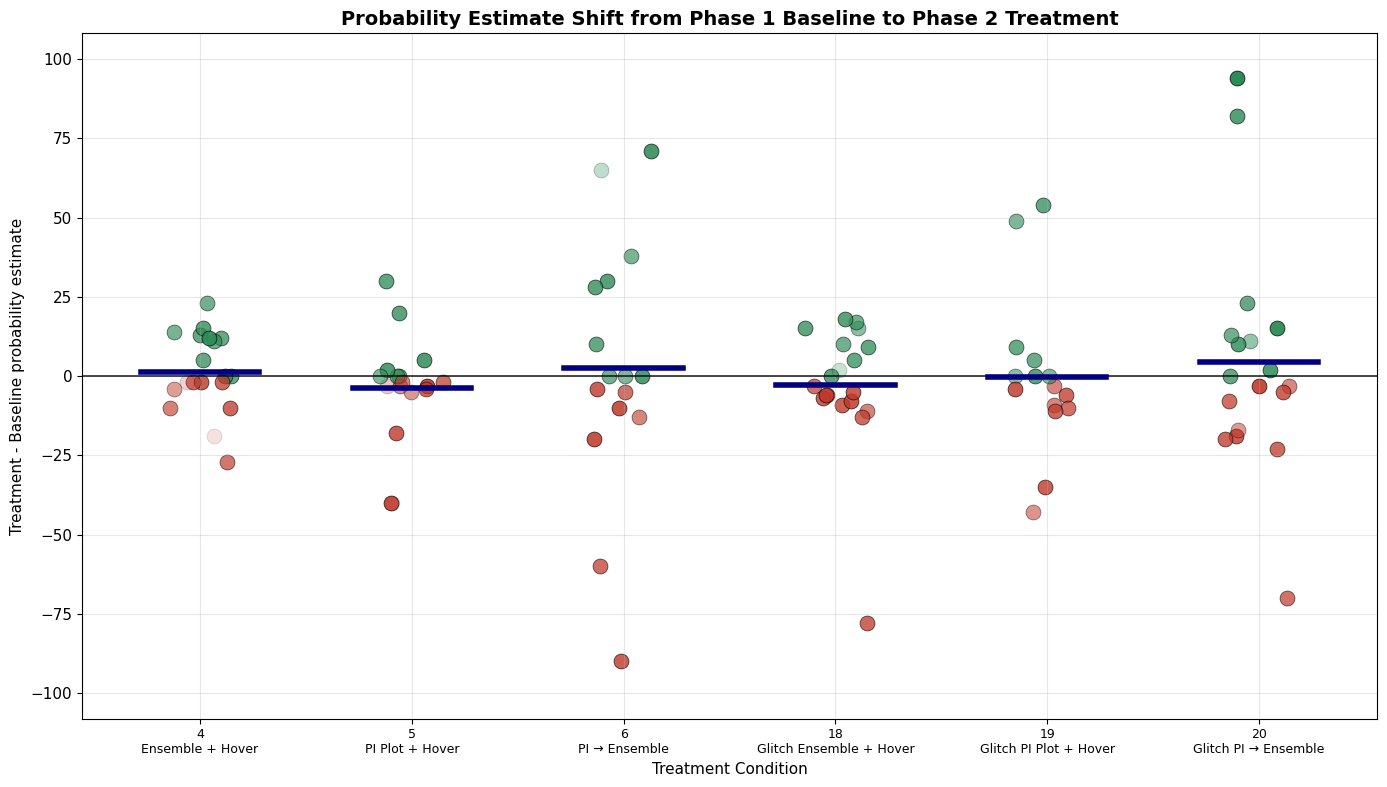

Shift summary for probability_estimate


,condition_number,condition_name,n,mean_shift,sd_shift,mean_interaction
0,4.0,Ensemble + Hover,19,1.42,12.55,11.53
1,5.0,PI Plot + Hover,17,-3.71,17.13,11.55
2,6.0,PI → Ensemble,16,2.50,40.66,11.99
3,18.0,Glitch Ensemble + Hover,19,-2.89,20.80,11.92
4,19.0,Glitch PI Plot + Hover,15,-0.27,25.16,11.69
5,20.0,Glitch PI → Ensemble,18,4.56,36.72,12.24


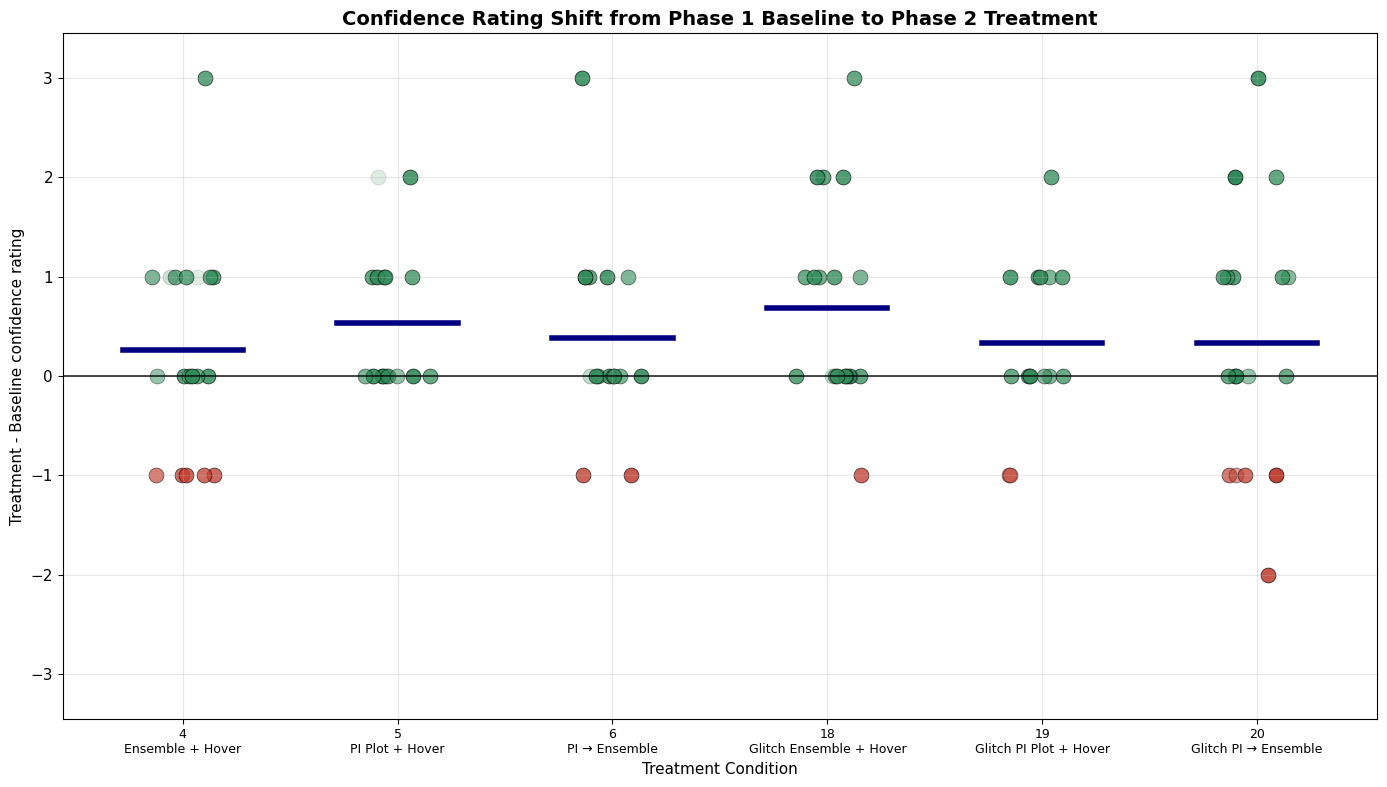

Shift summary for confidence_rating


,condition_number,condition_name,n,mean_shift,sd_shift,mean_interaction
0,4.0,Ensemble + Hover,19,0.26,1.05,11.53
1,5.0,PI Plot + Hover,17,0.53,0.72,11.55
2,6.0,PI → Ensemble,16,0.38,0.96,11.99
3,18.0,Glitch Ensemble + Hover,19,0.68,1.00,11.92
4,19.0,Glitch PI Plot + Hover,15,0.33,0.82,11.69
5,20.0,Glitch PI → Ensemble,18,0.33,1.28,12.24


In [6]:
def create_shift_plot(phase1_data, phase2_data, value_col, title, y_label, y_limits=None):
    baseline = (
        phase1_data.loc[phase1_data[value_col].notna(), ["participant_id", value_col]]
        .drop_duplicates(subset=["participant_id"], keep="last")
        .rename(columns={value_col: f"{value_col}_baseline"})
    )

    treatment = phase2_data[
        phase2_data["condition_number"].notna() & phase2_data[value_col].notna()
    ].copy()
    treatment = treatment[treatment["condition_number"] != 0].copy()

    merged = treatment.merge(baseline, on="participant_id", how="inner")
    if merged.empty:
        print(f"No matched baseline/treatment rows found for {value_col}")
        return None

    merged["shift"] = merged[value_col] - merged[f"{value_col}_baseline"]
    merged["interaction_freq"] = merged["interaction_freq"].fillna(0)

    if merged["interaction_freq"].nunique() > 1:
        freq_min = merged["interaction_freq"].min()
        freq_max = merged["interaction_freq"].max()
        merged["opacity"] = 0.15 + (merged["interaction_freq"] - freq_min) / (freq_max - freq_min) * 0.85
    else:
        merged["opacity"] = 0.75

    summary = (
        merged.groupby(["condition_number", "condition_name"])
        .agg(
            n=("participant_id", "size"),
            mean_shift=("shift", "mean"),
            sd_shift=("shift", "std"),
            mean_interaction=("interaction_freq", "mean"),
        )
        .round(2)
        .reset_index()
        .sort_values("condition_number")
    )

    position_map = {
        int(condition_number): index + 1
        for index, condition_number in enumerate(summary["condition_number"].astype(int).tolist())
    }

    plot_data = merged.copy()
    plot_data["x_position"] = plot_data["condition_number"].astype(int).map(position_map)

    np.random.seed(42)
    jitter = np.random.uniform(-0.16, 0.16, len(plot_data))
    colors = np.where(plot_data["shift"] >= 0, "#2E8B57", "#C0392B")

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.axhline(0, color="black", linewidth=1.25, alpha=0.8)

    for x_pos, shift, alpha, color in zip(plot_data["x_position"] + jitter, plot_data["shift"], plot_data["opacity"], colors):
        ax.scatter(x_pos, shift, s=115, alpha=alpha, color=color, edgecolors="black", linewidth=0.5)

    for _, row in summary.iterrows():
        x_pos = position_map[int(row["condition_number"])]
        ax.plot([x_pos - 0.28, x_pos + 0.28], [row["mean_shift"], row["mean_shift"]], color="navy", linewidth=4)

    labels = [
        f"{int(row.condition_number)}\n{row.condition_name}"
        for row in summary.itertuples(index=False)
    ]
    ax.set_xticks(list(position_map.values()))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel("Treatment Condition")
    ax.set_ylabel(y_label)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True, axis="y", alpha=0.3)

    if y_limits is not None:
        ax.set_ylim(*y_limits)
    else:
        max_abs_shift = max(abs(plot_data["shift"].min()), abs(plot_data["shift"].max()))
        padded_limit = max_abs_shift * 1.15 if max_abs_shift else 1
        ax.set_ylim(-padded_limit, padded_limit)

    plt.tight_layout()
    plt.show()

    print(f"Shift summary for {value_col}")
    display(summary)
    return plot_data, summary


probability_shift_data, probability_shift_summary = create_shift_plot(
    phase1_data,
    phase2_data,
    value_col="probability_estimate",
    title="Probability Estimate Shift from Phase 1 Baseline to Phase 2 Treatment",
    y_label="Treatment - Baseline probability estimate",
)

confidence_shift_data, confidence_shift_summary = create_shift_plot(
    phase1_data,
    phase2_data,
    value_col="confidence_rating",
    title="Confidence Rating Shift from Phase 1 Baseline to Phase 2 Treatment",
    y_label="Treatment - Baseline confidence rating",
)

## 4. Trust and Interaction Measures

Trust measures are combined directly across datasets. Interaction measures use the shared survey items available in both `dist 3` and `first9`; the non-overlapping `interface_exploration` / `company_communication` item is excluded from the combined interaction comparison.


In [7]:
FIRST9_DIR = Path("./data/first9")
FIRST9_CONDITIONS = {1, 2, 3, 9}
ANALYSIS_CONDITION_SET = set(treatment_conditions) | FIRST9_CONDITIONS

RAW_INTERACTION_NUMERIC_KEYS = [
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_exploration",
    "company_communication",
    "interface_responsiveness",
    "user_communication",
    "customer_communication",
    "personal_conversation",
    "interface_interaction",
    "interface_sensitivity",
]

COMBINED_INTERACTION_QUESTION_KEYS = [
    "navigation_control",
    "content_control",
    "pace_control",
    "interface_responsiveness",
    "peer_communication",
    "personal_conversation",
    "interface_interaction",
    "interface_sensitivity",
]

TRUST_QUESTION_KEYS = [
    "skeptical_rating",
    "data_trust",
    "usability_difficulty",
    "comprehension_ease",
]

DEMOGRAPHIC_QUESTION_KEYS = [
    "respect_others",
    "good_word_everyone",
    "retreat_from_others",
    "avoid_contacts",
]


def parse_response_json(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        return json.loads(value)
    except Exception:
        return {}



def expand_response_columns(data):
    parsed = data["response"].apply(parse_response_json)
    expanded = pd.json_normalize(parsed)
    expanded = expanded.apply(lambda col: pd.to_numeric(col, errors="ignore"))
    base = data.reset_index(drop=True).copy()
    overlap = [col for col in expanded.columns if col in base.columns]
    if overlap:
        base = base.drop(columns=overlap)
    return pd.concat([base, expanded], axis=1)



def load_dataset_from_directory(data_dir, source_name):
    csv_files = sorted(data_dir.glob(CSV_PATTERN))
    if not csv_files:
        return pd.DataFrame()

    loaded = []
    for file_path in csv_files:
        participant_rows = load_participant_data(file_path)
        participant_rows["source_dataset"] = source_name
        loaded.append(participant_rows)

    dataset = pd.concat(loaded, ignore_index=True)
    dataset = dataset[dataset["participant_id"].notna()].copy()
    dataset = dataset[~dataset["participant_id"].astype(str).str.lower().eq("test")].copy()
    return dataset



def coalesce_first_available(data, candidates):
    available = [col for col in candidates if col in data.columns]
    if not available:
        return pd.Series(np.nan, index=data.index, dtype="float64")
    return data[available].bfill(axis=1).iloc[:, 0]


relevant_trials = relevant_trials.copy()
relevant_trials["source_dataset"] = "dist3"

first9_data = load_dataset_from_directory(FIRST9_DIR, source_name="first9")
first9_selected_trials = first9_data[
    first9_data["trial_type"].isin(relevant_trial_types)
    & first9_data["condition_number"].isin(FIRST9_CONDITIONS)
].copy()

if "interaction_log" not in first9_selected_trials.columns:
    first9_selected_trials["interaction_log"] = ""

first9_selected_trials["interaction_freq"] = np.log1p(
    first9_selected_trials["interaction_log"].fillna("").astype(str).str.len()
)

survey_analysis_trials = pd.concat(
    [relevant_trials, first9_selected_trials],
    ignore_index=True,
    sort=False,
)
survey_analysis_trials = survey_analysis_trials[
    survey_analysis_trials["condition_number"].isin(ANALYSIS_CONDITION_SET)
].copy()

survey_rows = survey_analysis_trials[survey_analysis_trials["trial_type"] == "trust-survey"].copy()
survey_expanded = expand_response_columns(survey_rows)

for col in RAW_INTERACTION_NUMERIC_KEYS + TRUST_QUESTION_KEYS + DEMOGRAPHIC_QUESTION_KEYS:
    if col in survey_expanded.columns:
        survey_expanded[col] = pd.to_numeric(survey_expanded[col], errors="coerce")

survey_expanded["peer_communication"] = pd.to_numeric(
    coalesce_first_available(survey_expanded, ["user_communication", "customer_communication"]),
    errors="coerce",
)

analysis_interaction_data = survey_expanded[
    survey_expanded[COMBINED_INTERACTION_QUESTION_KEYS].notna().any(axis=1)
].copy()
analysis_trust_data = survey_expanded[survey_expanded["skeptical_rating"].notna()].copy()
analysis_phase2_data = survey_analysis_trials[
    (survey_analysis_trials["trial_type"] == "prediction-task")
    & (survey_analysis_trials["phase"] == 2)
].copy()

analysis_condition_lookup = (
    survey_analysis_trials.loc[
        survey_analysis_trials["condition_number"].notna(),
        ["condition_number", "condition_name", "source_dataset"],
    ]
    .drop_duplicates()
    .sort_values(["condition_number", "source_dataset"])
    .reset_index(drop=True)
)

print("Combined analysis datasets")
print(f"  Dist 3 relevant rows: {len(relevant_trials)}")
print(f"  First9 rows added for conditions {sorted(FIRST9_CONDITIONS)}: {len(first9_selected_trials)}")
print(f"  Combined trust survey rows: {len(analysis_trust_data)}")
print(f"  Combined interaction survey rows: {len(analysis_interaction_data)}")
print(f"  Combined phase 2 prediction rows: {len(analysis_phase2_data)}")
print(
    "  Interaction analysis uses the 8 shared survey items across dist3 and first9; "
    "`interface_exploration` and `company_communication` are intentionally excluded."
)
print("\nConditions included in the combined trust / interaction analysis:")
display(analysis_condition_lookup)


Combined analysis datasets
  Dist 3 relevant rows: 936
  First9 rows added for conditions [1, 2, 3, 9]: 518
  Combined trust survey rows: 178
  Combined interaction survey rows: 178
  Combined phase 2 prediction rows: 178
  Interaction analysis uses the 8 shared survey items across dist3 and first9; `interface_exploration` and `company_communication` are intentionally excluded.

Conditions included in the combined trust / interaction analysis:


,condition_number,condition_name,source_dataset
0,1.0,Baseline,first9
1,2.0,PI Plot,first9
2,3.0,Ensemble Plot,first9
3,4.0,Ensemble + Hover,dist3
4,5.0,PI Plot + Hover,dist3
5,6.0,PI → Ensemble,dist3
6,9.0,Combined PI + Ensemble,first9
7,18.0,Glitch Ensemble + Hover,dist3
8,19.0,Glitch PI Plot + Hover,dist3
9,20.0,Glitch PI → Ensemble,dist3


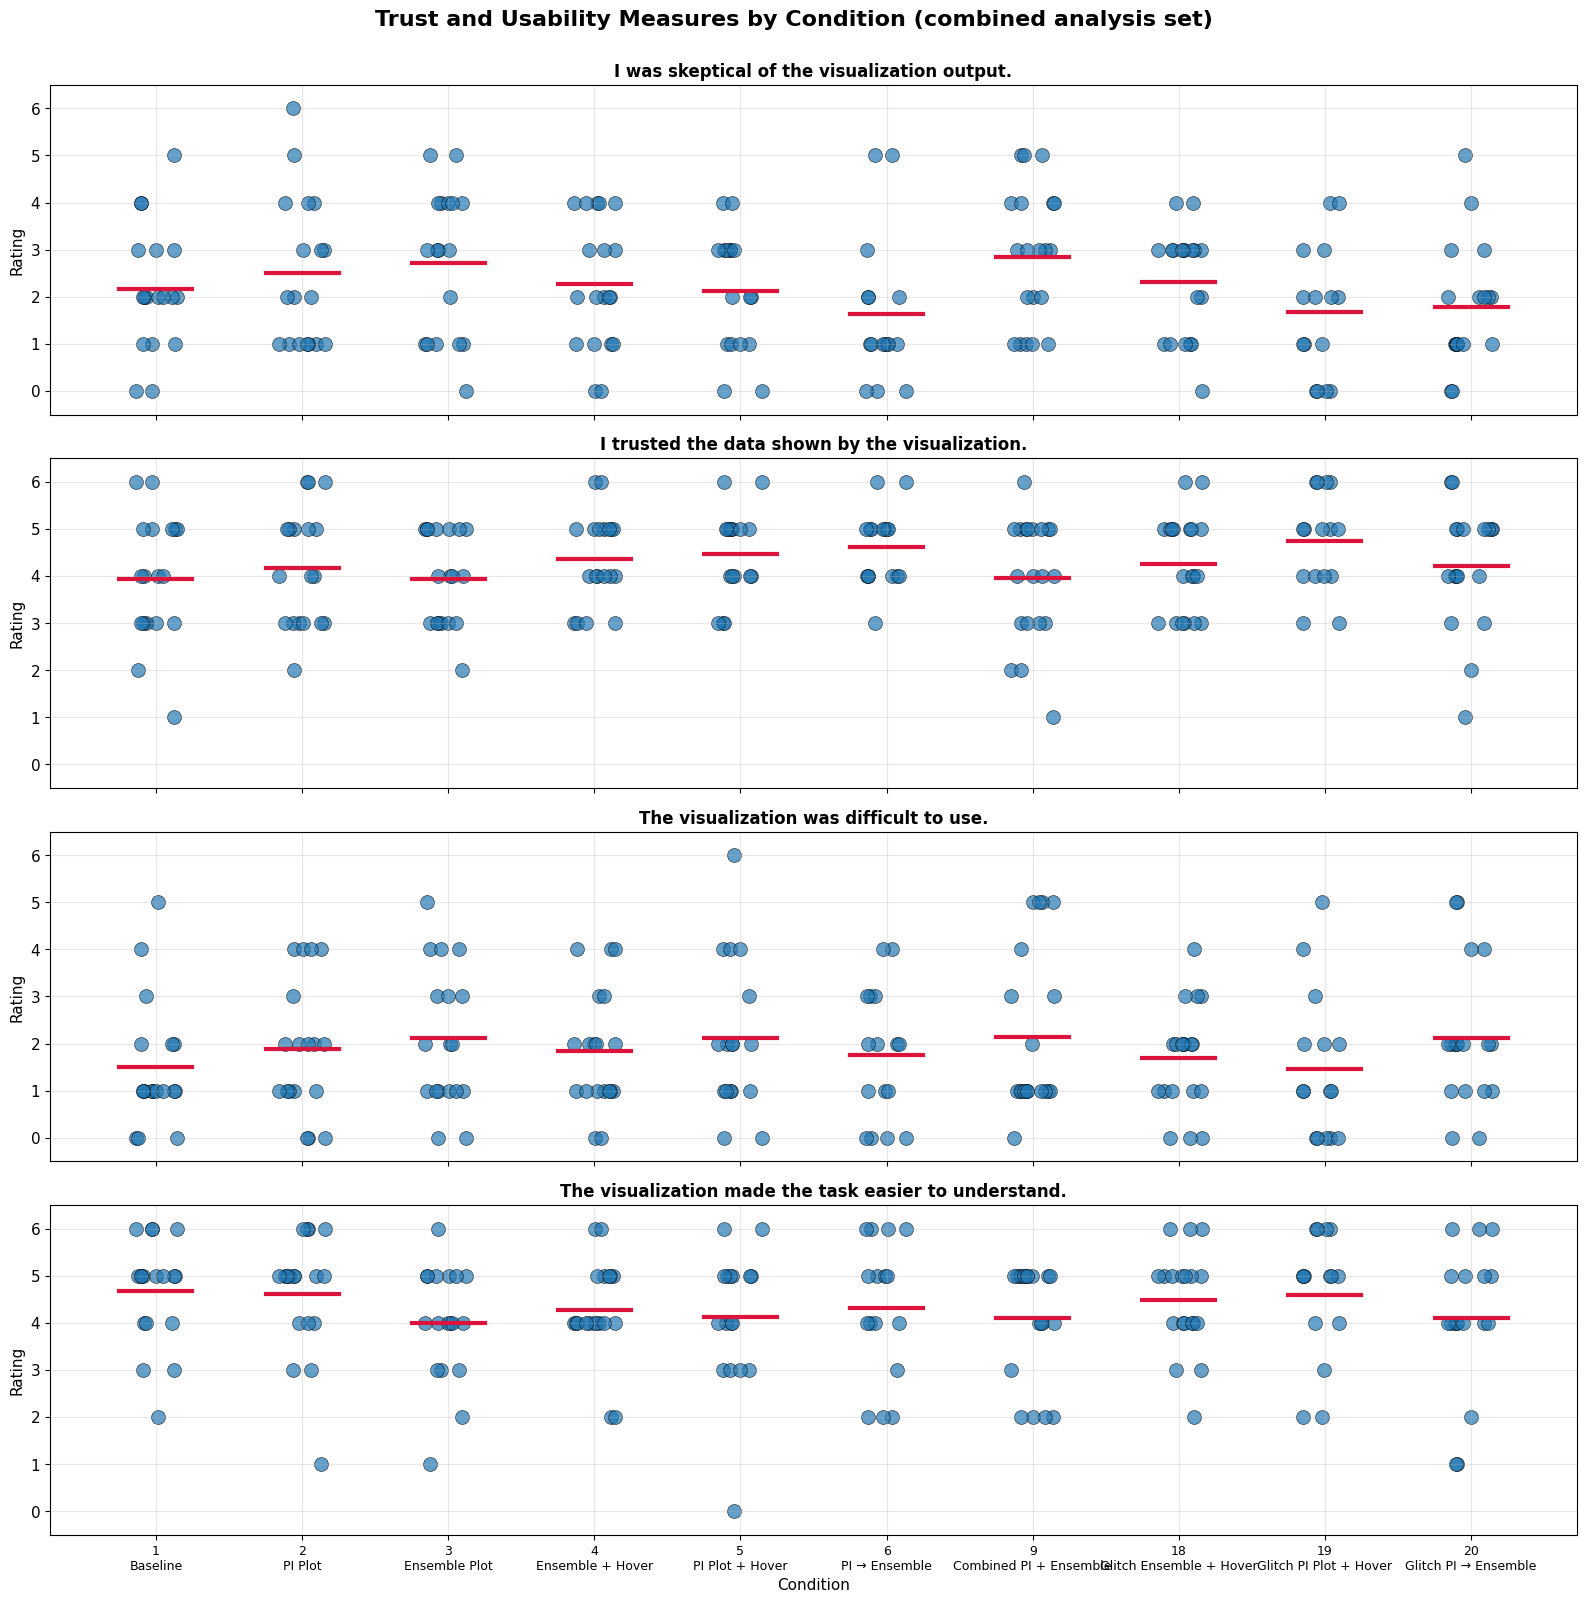

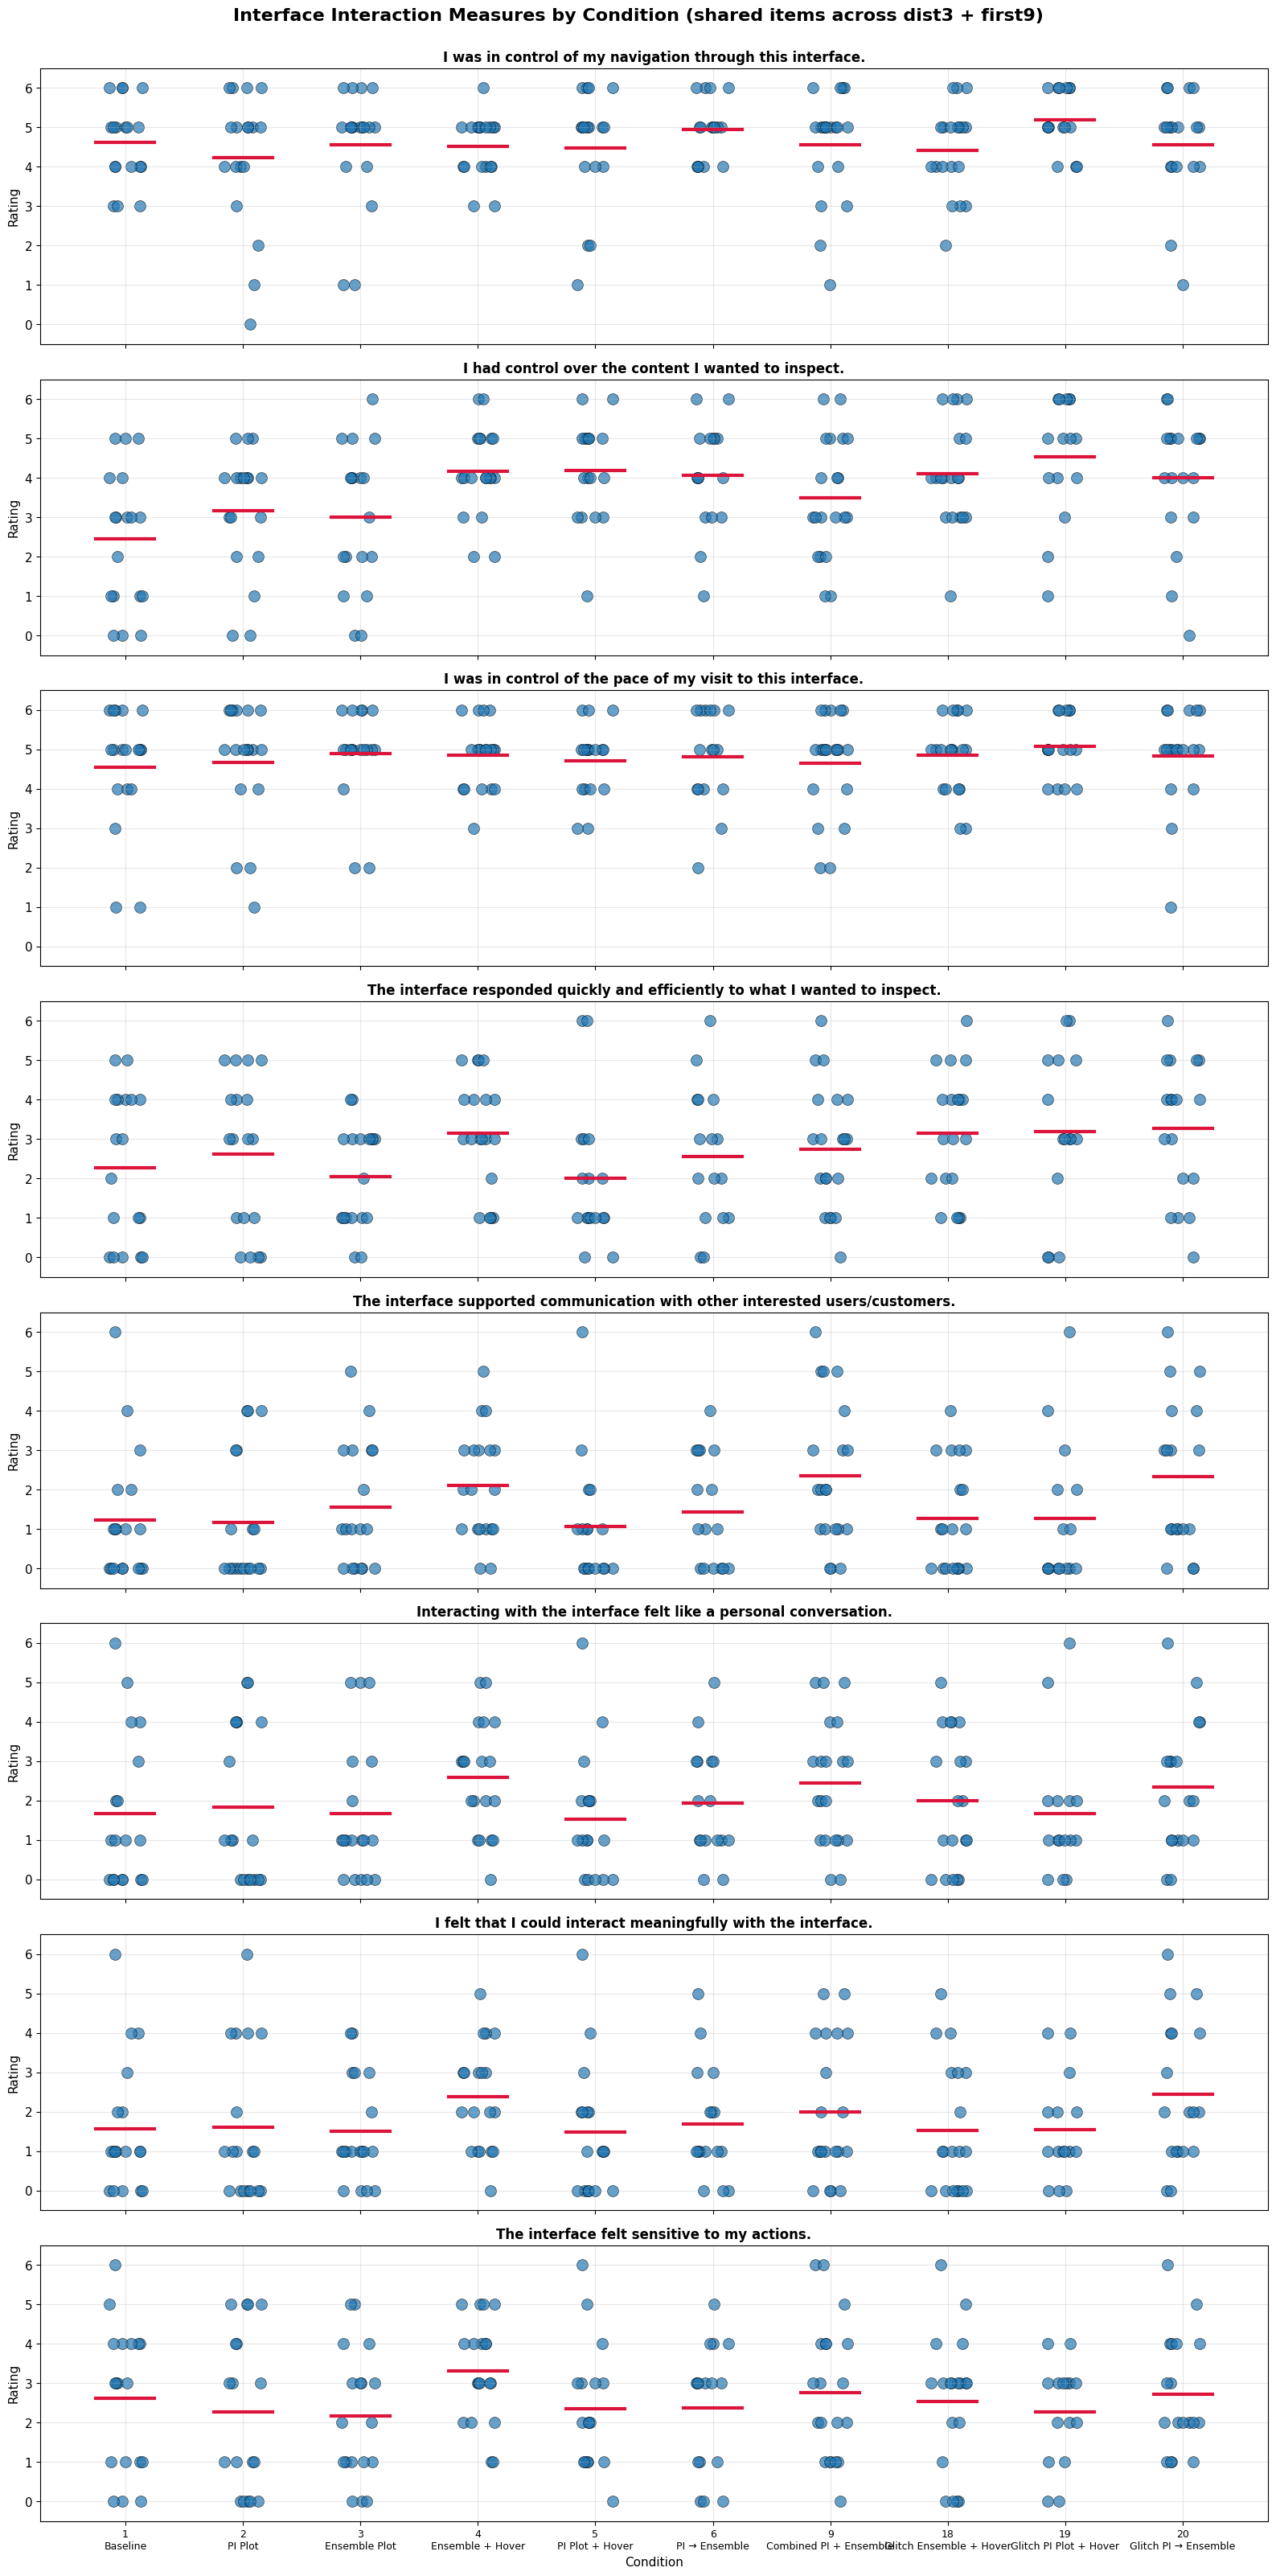

In [8]:
interaction_questions = [
    {"type": "navigation_control", "prompt": "I was in control of my navigation through this interface."},
    {"type": "content_control", "prompt": "I had control over the content I wanted to inspect."},
    {"type": "pace_control", "prompt": "I was in control of the pace of my visit to this interface."},
    {"type": "interface_responsiveness", "prompt": "The interface responded quickly and efficiently to what I wanted to inspect."},
    {"type": "peer_communication", "prompt": "The interface supported communication with other interested users/customers."},
    {"type": "personal_conversation", "prompt": "Interacting with the interface felt like a personal conversation."},
    {"type": "interface_interaction", "prompt": "I felt that I could interact meaningfully with the interface."},
    {"type": "interface_sensitivity", "prompt": "The interface felt sensitive to my actions."},
]

trust_questions = [
    {"type": "skeptical_rating", "prompt": "I was skeptical of the visualization output."},
    {"type": "data_trust", "prompt": "I trusted the data shown by the visualization."},
    {"type": "usability_difficulty", "prompt": "The visualization was difficult to use."},
    {"type": "comprehension_ease", "prompt": "The visualization made the task easier to understand."},
]


def create_sectioned_survey_plots(data, questions, section_title, exclude_baseline=True):
    if data.empty:
        print(f"No data available for {section_title}")
        return

    condition_frame = (
        data[["condition_number", "condition_name"]]
        .dropna()
        .drop_duplicates()
        .sort_values("condition_number")
    )
    if exclude_baseline:
        condition_frame = condition_frame[condition_frame["condition_number"] != 0]

    position_map = {
        int(row.condition_number): index + 1
        for index, row in enumerate(condition_frame.itertuples(index=False))
    }
    labels = [
        f"{int(row.condition_number)}\n{row.condition_name}"
        for row in condition_frame.itertuples(index=False)
    ]

    fig, axes = plt.subplots(len(questions), 1, figsize=(16, 4 * len(questions)), sharex=True)
    if len(questions) == 1:
        axes = [axes]

    for ax, question in zip(axes, questions):
        key = question["type"]
        plot_rows = data[data[key].notna() & data["condition_number"].notna()].copy()
        if exclude_baseline:
            plot_rows = plot_rows[plot_rows["condition_number"] != 0].copy()

        if plot_rows.empty:
            ax.set_title(question["prompt"], fontsize=12, fontweight="bold")
            ax.text(0.5, 0.5, "No data", transform=ax.transAxes, ha="center", va="center")
            continue

        plot_rows["x_position"] = plot_rows["condition_number"].astype(int).map(position_map)
        np.random.seed(42)
        jitter = np.random.uniform(-0.16, 0.16, len(plot_rows))
        ax.scatter(
            plot_rows["x_position"] + jitter,
            plot_rows[key],
            alpha=0.7,
            s=100,
            edgecolors="black",
            linewidth=0.5,
            color="#1f77b4",
        )

        means = plot_rows.groupby("condition_number")[key].mean()
        for condition_number, mean_value in means.items():
            x_pos = position_map[int(condition_number)]
            ax.plot([x_pos - 0.25, x_pos + 0.25], [mean_value, mean_value], color="crimson", linewidth=3)

        ax.set_title(question["prompt"], fontsize=12, fontweight="bold")
        ax.set_ylabel("Rating")
        ax.set_ylim(-0.5, 6.5)
        ax.grid(True, axis="y", alpha=0.3)

    axes[-1].set_xticks(list(position_map.values()))
    axes[-1].set_xticklabels(labels, fontsize=9)
    axes[-1].set_xlabel("Condition")
    fig.suptitle(section_title, fontsize=16, fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()


create_sectioned_survey_plots(
    analysis_trust_data,
    trust_questions,
    section_title="Trust and Usability Measures by Condition (combined analysis set)",
)

create_sectioned_survey_plots(
    analysis_interaction_data,
    interaction_questions,
    section_title="Interface Interaction Measures by Condition (shared items across dist3 + first9)",
)


## 5. Composite Scores, Interaction Frequency, and Feedback Page

Composite trust, composite interaction, and interaction frequency use the combined analysis dataset from section 4. Feedback-page analyses remain dist 3 only because the corresponding feedback rows are not available in `data/first9`.


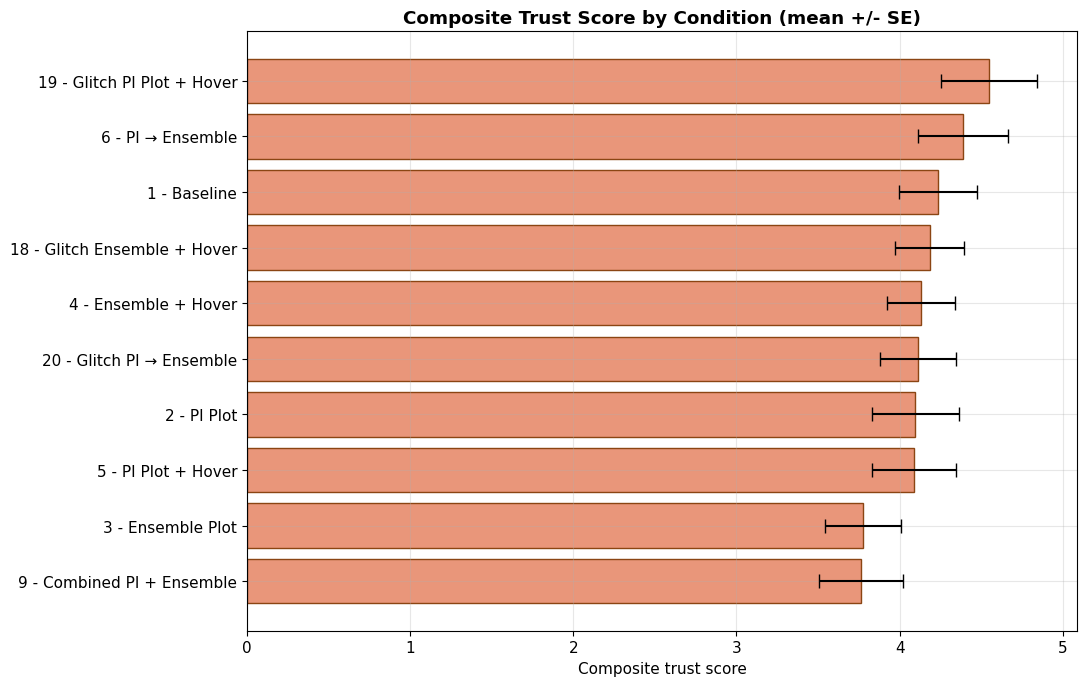

,condition_number,condition_name,mean_score,sd_score,n,se_score
0,19.0,Glitch PI Plot + Hover,4.550,1.143,15,0.295121
1,6.0,PI → Ensemble,4.391,1.103,16,0.275750
2,1.0,Baseline,4.236,1.016,18,0.239473
3,18.0,Glitch Ensemble + Hover,4.184,0.931,19,0.213586
4,4.0,Ensemble + Hover,4.132,0.918,19,0.210604
5,20.0,Glitch PI → Ensemble,4.111,0.990,18,0.233345
6,2.0,PI Plot,4.097,1.128,18,0.265872
7,5.0,PI Plot + Hover,4.088,1.064,17,0.258058
8,3.0,Ensemble Plot,3.778,0.988,18,0.232874
9,9.0,Combined PI + Ensemble,3.762,1.154,20,0.258042


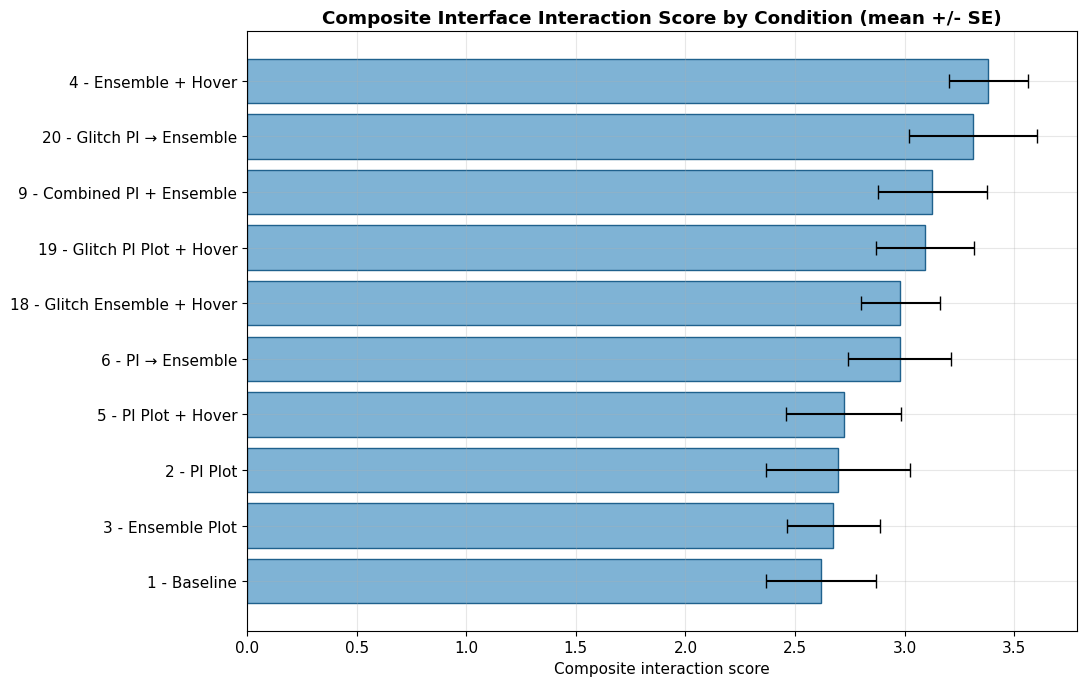

,condition_number,condition_name,mean_score,sd_score,n,se_score
0,4.0,Ensemble + Hover,3.382,0.782,19,0.179403
1,20.0,Glitch PI → Ensemble,3.312,1.245,18,0.293449
2,9.0,Combined PI + Ensemble,3.125,1.110,20,0.248204
3,19.0,Glitch PI Plot + Hover,3.092,0.865,15,0.223342
4,18.0,Glitch Ensemble + Hover,2.980,0.780,19,0.178944
5,6.0,PI → Ensemble,2.977,0.938,16,0.234500
6,5.0,PI Plot + Hover,2.721,1.078,17,0.261453
7,2.0,PI Plot,2.694,1.393,18,0.328333
8,3.0,Ensemble Plot,2.674,0.895,18,0.210954
9,1.0,Baseline,2.618,1.072,18,0.252673


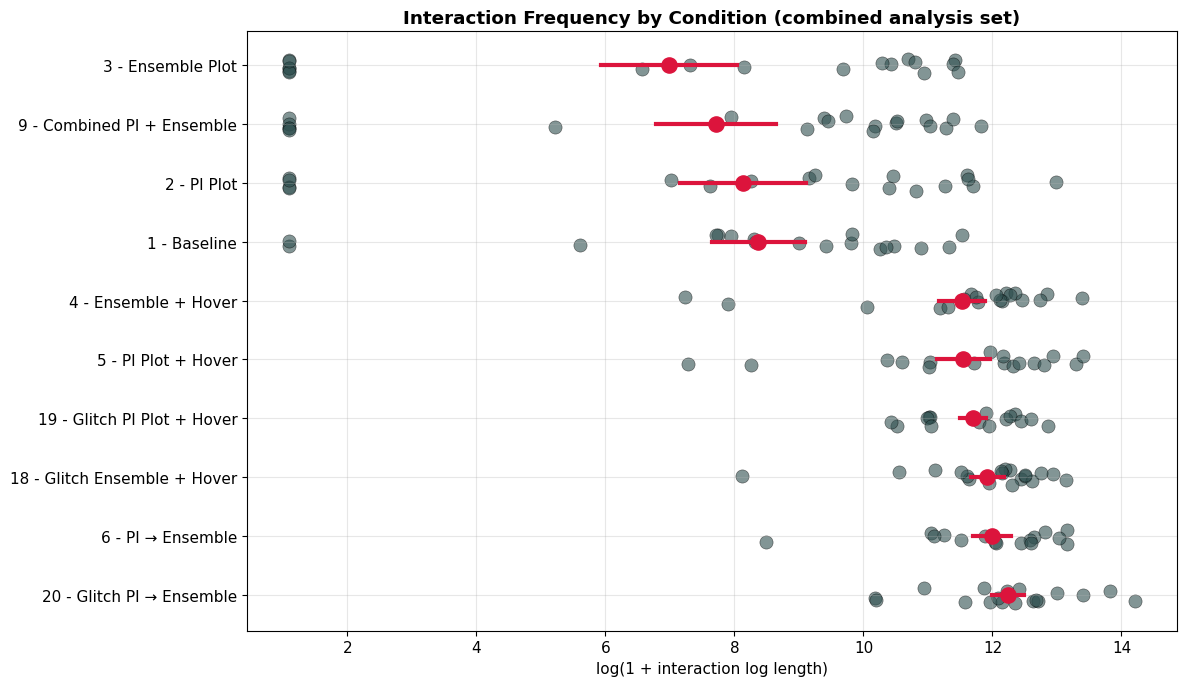

,condition_number,condition_name,mean_freq,sd_freq,n,se_freq
9,20.0,Glitch PI → Ensemble,12.241,1.076,18,0.253616
5,6.0,PI → Ensemble,11.988,1.172,16,0.293000
7,18.0,Glitch Ensemble + Hover,11.917,1.116,19,0.256028
8,19.0,Glitch PI Plot + Hover,11.694,0.789,15,0.203719
4,5.0,PI Plot + Hover,11.550,1.683,17,0.408187
3,4.0,Ensemble + Hover,11.529,1.568,19,0.359724
0,1.0,Baseline,8.373,3.040,18,0.716535
1,2.0,PI Plot,8.131,4.149,18,0.977929
6,9.0,Combined PI + Ensemble,7.711,4.163,20,0.930875
2,3.0,Ensemble Plot,6.983,4.489,18,1.058067


Feedback page rows: 104


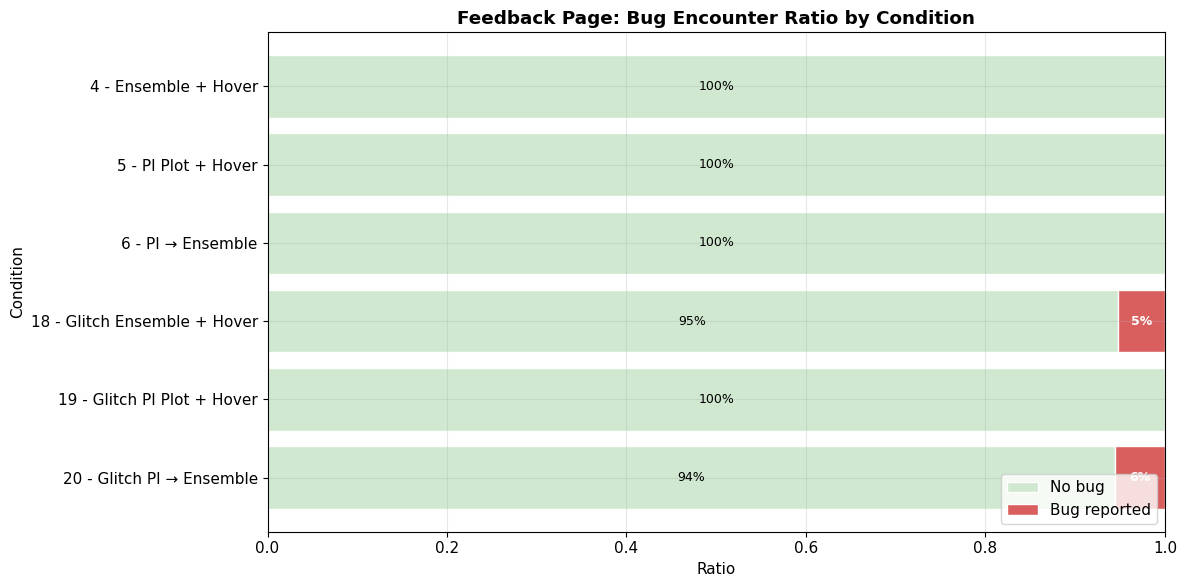

encounter_bug,condition_number,condition_name,No bug,Bug reported,No bug ratio,Bug reported ratio
0,4.0,Ensemble + Hover,19,0,1.000000,0.000000
1,5.0,PI Plot + Hover,17,0,1.000000,0.000000
2,6.0,PI → Ensemble,16,0,1.000000,0.000000
3,18.0,Glitch Ensemble + Hover,18,1,0.947368,0.052632
4,19.0,Glitch PI Plot + Hover,15,0,1.000000,0.000000
5,20.0,Glitch PI → Ensemble,17,1,0.944444,0.055556


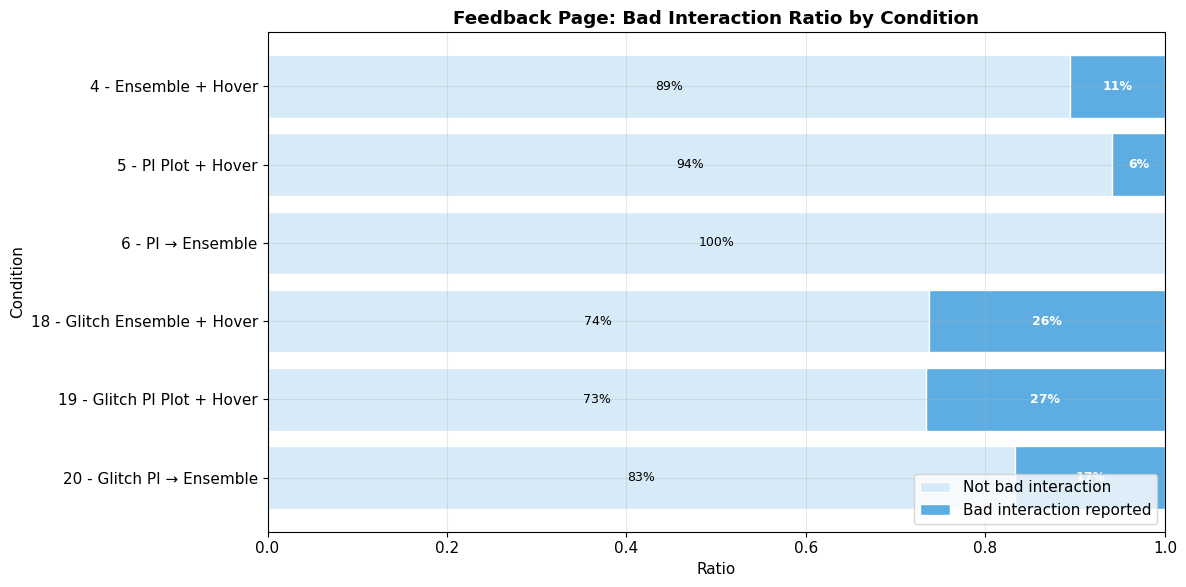

annoying_design,condition_number,condition_name,Not bad interaction,Bad interaction reported,Not bad interaction ratio,Bad interaction reported ratio
0,4.0,Ensemble + Hover,17,2,0.894737,0.105263
1,5.0,PI Plot + Hover,16,1,0.941176,0.058824
2,6.0,PI → Ensemble,16,0,1.000000,0.000000
3,18.0,Glitch Ensemble + Hover,14,5,0.736842,0.263158
4,19.0,Glitch PI Plot + Hover,11,4,0.733333,0.266667
5,20.0,Glitch PI → Ensemble,15,3,0.833333,0.166667


Feedback text box responses: bug elaboration


Feedback text box responses: bad interaction elaboration


In [9]:
import html
from IPython.display import HTML


def summarize_composite_scale(data, question_keys, score_column, reverse_columns=None):
    reverse_columns = set(reverse_columns or [])

    valid_data = data[data["condition_number"].notna()].copy()
    valid_data = valid_data[valid_data["condition_number"] != 0].copy()

    for col in question_keys:
        if col in reverse_columns:
            valid_data[f"{col}_scored"] = 6 - valid_data[col]
        else:
            valid_data[f"{col}_scored"] = valid_data[col]

    scored_columns = [f"{col}_scored" for col in question_keys]
    valid_data[score_column] = valid_data[scored_columns].mean(axis=1, skipna=True)

    summary = (
        valid_data.groupby(["condition_number", "condition_name"])
        .agg(
            mean_score=(score_column, "mean"),
            sd_score=(score_column, "std"),
            n=(score_column, "count"),
        )
        .round(3)
        .reset_index()
    )
    summary["se_score"] = summary["sd_score"] / np.sqrt(summary["n"])
    return valid_data, summary



def plot_condition_score_summary(summary, value_col, error_col, x_label, title, color, edgecolor):
    if summary.empty:
        print(f"No data available for {title}")
        return

    plot_summary = summary.sort_values(value_col, ascending=False).reset_index(drop=True)

    plt.figure(figsize=(11, 7))
    plt.barh(
        range(len(plot_summary)),
        plot_summary[value_col],
        xerr=plot_summary[error_col],
        color=color,
        edgecolor=edgecolor,
        capsize=5,
    )
    plt.yticks(
        range(len(plot_summary)),
        [
            f"{int(row.condition_number)} - {row.condition_name}"
            for row in plot_summary.itertuples(index=False)
        ],
    )
    plt.gca().invert_yaxis()
    plt.xlabel(x_label)
    plt.title(title, fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()



def analyze_composite_trust_score(data):
    trust_columns = [
        "skeptical_rating",
        "data_trust",
        "usability_difficulty",
        "comprehension_ease",
    ]
    reverse_columns = ["skeptical_rating", "usability_difficulty"]

    valid_data, summary = summarize_composite_scale(
        data,
        trust_columns,
        score_column="composite_trust_score",
        reverse_columns=reverse_columns,
    )

    plot_condition_score_summary(
        summary,
        value_col="mean_score",
        error_col="se_score",
        x_label="Composite trust score",
        title="Composite Trust Score by Condition (mean +/- SE)",
        color="#E9967A",
        edgecolor="#8B4513",
    )

    display(summary.sort_values("mean_score", ascending=False).reset_index(drop=True))
    return valid_data, summary



def analyze_composite_interaction_score(data):
    valid_data, summary = summarize_composite_scale(
        data,
        COMBINED_INTERACTION_QUESTION_KEYS,
        score_column="composite_interaction_score",
    )

    plot_condition_score_summary(
        summary,
        value_col="mean_score",
        error_col="se_score",
        x_label="Composite interaction score",
        title="Composite Interface Interaction Score by Condition (mean +/- SE)",
        color="#7FB3D5",
        edgecolor="#1F618D",
    )

    display(summary.sort_values("mean_score", ascending=False).reset_index(drop=True))
    return valid_data, summary



def create_interaction_freq_dot_plot(data):
    valid_data = data[data["condition_number"].notna()].copy()
    valid_data = valid_data[valid_data["condition_number"] != 0].copy()

    summary = (
        valid_data.groupby(["condition_number", "condition_name"])
        .agg(
            mean_freq=("interaction_freq", "mean"),
            sd_freq=("interaction_freq", "std"),
            n=("interaction_freq", "count"),
        )
        .round(3)
        .reset_index()
        .sort_values("mean_freq", ascending=False)
    )
    summary["se_freq"] = summary["sd_freq"] / np.sqrt(summary["n"])

    label_order = [row.condition_name for row in summary.itertuples(index=False)]
    y_map = {label: index for index, label in enumerate(label_order)}

    plt.figure(figsize=(12, 7))
    np.random.seed(42)
    for _, row in valid_data.iterrows():
        y_pos = y_map[row["condition_name"]] + np.random.uniform(-0.14, 0.14)
        plt.scatter(
            row["interaction_freq"],
            y_pos,
            alpha=0.6,
            s=90,
            color="#2F4F4F",
            edgecolors="black",
            linewidth=0.4,
        )

    for _, row in summary.iterrows():
        y_pos = y_map[row["condition_name"]]
        plt.plot(
            [row["mean_freq"] - row["se_freq"], row["mean_freq"] + row["se_freq"]],
            [y_pos, y_pos],
            color="crimson",
            linewidth=3,
        )
        plt.scatter(row["mean_freq"], y_pos, color="crimson", s=120, zorder=3)

    plt.yticks(
        range(len(label_order)),
        [
            f"{int(row.condition_number)} - {row.condition_name}"
            for row in summary.itertuples(index=False)
        ],
    )
    plt.xlabel("log(1 + interaction log length)")
    plt.title("Interaction Frequency by Condition (combined analysis set)", fontweight="bold")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(summary)
    return summary



def normalize_yes_no(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in {"yes", "y", "true", "1"}:
        return "Yes"
    if text in {"no", "n", "false", "0"}:
        return "No"
    return np.nan



def prepare_feedback_page_data(data):
    feedback_rows = data[
        (data["trial_type"] == "interaction-feedback")
        & (data["phase"] == 2)
        & data["condition_number"].notna()
    ].copy()
    feedback_rows = feedback_rows[feedback_rows["condition_number"] != 0].copy()

    parsed_feedback = feedback_rows["response"].apply(parse_response_json).apply(pd.Series)
    feedback_rows = pd.concat(
        [feedback_rows.reset_index(drop=True), parsed_feedback.reset_index(drop=True)],
        axis=1,
    )

    for col in ["encounter_bug", "annoying_design"]:
        if col in feedback_rows.columns:
            feedback_rows[col] = feedback_rows[col].apply(normalize_yes_no)

    for col in ["bug_elaboration", "annoying_elaboration"]:
        if col in feedback_rows.columns:
            feedback_rows[col] = feedback_rows[col].fillna("").astype(str).str.strip()

    return feedback_rows.sort_values(["condition_number", "participant_id"]).reset_index(drop=True)



def create_feedback_ratio_stacked_bar(
    feedback_data,
    response_col,
    title,
    no_label,
    yes_label,
    no_color,
    yes_color,
):
    plot_rows = feedback_data[feedback_data[response_col].notna()].copy()
    if plot_rows.empty:
        print(f"No data available for {title}")
        return pd.DataFrame()

    summary = (
        plot_rows.groupby(["condition_number", "condition_name", response_col])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=["No", "Yes"], fill_value=0)
        .reset_index()
        .sort_values("condition_number")
    )
    summary["total"] = summary["No"] + summary["Yes"]
    summary["no_ratio"] = np.where(summary["total"] > 0, summary["No"] / summary["total"], 0)
    summary["yes_ratio"] = np.where(summary["total"] > 0, summary["Yes"] / summary["total"], 0)

    y_pos = np.arange(len(summary))
    labels = [
        f"{int(row.condition_number)} - {row.condition_name}"
        for row in summary.itertuples(index=False)
    ]

    plt.figure(figsize=(12, 6))
    plt.barh(y_pos, summary["no_ratio"], color=no_color, edgecolor="white", label=no_label)
    plt.barh(
        y_pos,
        summary["yes_ratio"],
        left=summary["no_ratio"],
        color=yes_color,
        edgecolor="white",
        label=yes_label,
    )

    for idx, row in summary.iterrows():
        if row["no_ratio"] > 0.05:
            plt.text(
                row["no_ratio"] / 2,
                idx,
                f"{row['no_ratio']:.0%}",
                ha="center",
                va="center",
                color="black",
                fontsize=9,
            )
        if row["yes_ratio"] > 0.05:
            plt.text(
                row["no_ratio"] + row["yes_ratio"] / 2,
                idx,
                f"{row['yes_ratio']:.0%}",
                ha="center",
                va="center",
                color="white",
                fontsize=9,
                fontweight="bold",
            )

    plt.yticks(y_pos, labels)
    plt.xlim(0, 1)
    plt.xlabel("Ratio")
    plt.ylabel("Condition")
    plt.title(title, fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(True, axis="x", alpha=0.3)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    display(
        summary[
            [
                "condition_number",
                "condition_name",
                "No",
                "Yes",
                "no_ratio",
                "yes_ratio",
            ]
        ].rename(
            columns={
                "No": no_label,
                "Yes": yes_label,
                "no_ratio": f"{no_label} ratio",
                "yes_ratio": f"{yes_label} ratio",
            }
        )
    )
    return summary



def display_feedback_text_boxes(feedback_data, text_col, section_title):
    condition_rows = (
        feedback_data[["condition_number", "condition_name"]]
        .drop_duplicates()
        .sort_values("condition_number")
    )

    print(section_title)
    for row in condition_rows.itertuples(index=False):
        subset = feedback_data[
            (feedback_data["condition_number"] == row.condition_number)
            & feedback_data[text_col].ne("")
        ].copy()

        if subset.empty:
            content = "[no feedback submitted]"
        else:
            content = "\n".join(
                f"{participant_id}: {feedback}"
                for participant_id, feedback in subset[["participant_id", text_col]].itertuples(index=False)
            )

        box_html = f"""
        <div style="margin: 12px 0 20px 0;">
            <div style="font-weight: 600; margin-bottom: 6px;">{int(row.condition_number)} - {html.escape(str(row.condition_name))}</div>
            <div style="border: 1px solid #c9cdd3; border-radius: 8px; background: #f8f9fb; padding: 12px; white-space: pre-wrap; font-family: monospace; font-size: 12px; line-height: 1.5;">{html.escape(content)}</div>
        </div>
        """
        display(HTML(box_html))



def analyze_feedback_page(data):
    feedback_data = prepare_feedback_page_data(data)
    print(f"Feedback page rows: {len(feedback_data)}")

    if feedback_data.empty:
        print("No feedback page rows found.")
        return feedback_data, pd.DataFrame(), pd.DataFrame()

    bug_ratio_summary = create_feedback_ratio_stacked_bar(
        feedback_data,
        response_col="encounter_bug",
        title="Feedback Page: Bug Encounter Ratio by Condition",
        no_label="No bug",
        yes_label="Bug reported",
        no_color="#CFE8CF",
        yes_color="#D95F5F",
    )

    bad_interaction_ratio_summary = create_feedback_ratio_stacked_bar(
        feedback_data,
        response_col="annoying_design",
        title="Feedback Page: Bad Interaction Ratio by Condition",
        no_label="Not bad interaction",
        yes_label="Bad interaction reported",
        no_color="#D6EAF8",
        yes_color="#5DADE2",
    )

    display_feedback_text_boxes(
        feedback_data,
        text_col="bug_elaboration",
        section_title="Feedback text box responses: bug elaboration",
    )
    display_feedback_text_boxes(
        feedback_data,
        text_col="annoying_elaboration",
        section_title="Feedback text box responses: bad interaction elaboration",
    )

    return feedback_data, bug_ratio_summary, bad_interaction_ratio_summary


composite_trust_data, composite_trust_summary = analyze_composite_trust_score(analysis_trust_data)
composite_interaction_data, composite_interaction_summary = analyze_composite_interaction_score(analysis_interaction_data)
interaction_freq_summary = create_interaction_freq_dot_plot(analysis_phase2_data)
feedback_page_data, feedback_bug_ratio_summary, feedback_bad_interaction_ratio_summary = analyze_feedback_page(combined_data)


## 6. Mini-VLAT Accuracy by Bug/Bad-Design Feedback (Conditions 18-20)

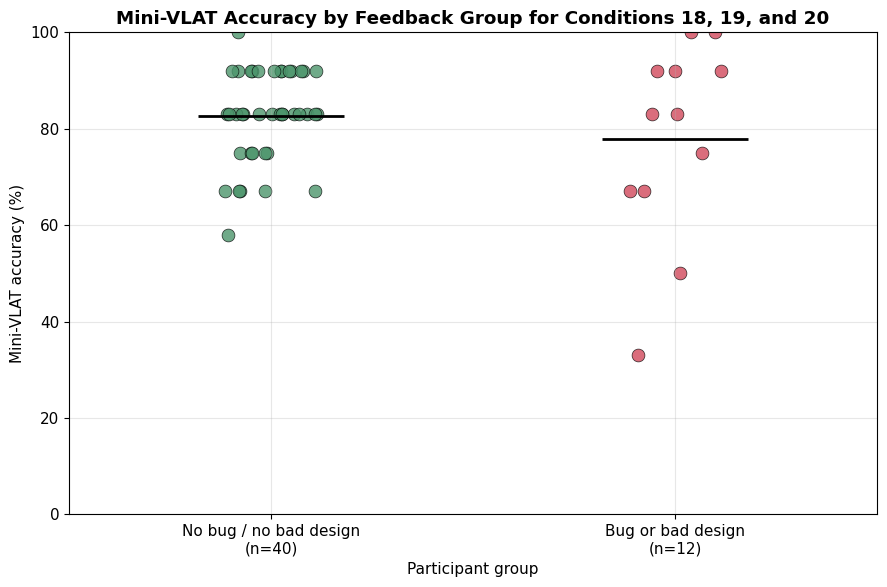

,participants,mean_accuracy,median_accuracy,sd_accuracy
feedback_group,,,,
No bug / no bad design,40,82.72,83.0,9.56
Bug or bad design,12,77.83,83.0,20.59


In [10]:
def plot_mini_vlat_accuracy_by_feedback_group(data, focus_conditions=(18, 19, 20)):
    feedback_rows = prepare_feedback_page_data(data)
    feedback_rows = feedback_rows[feedback_rows["condition_number"].isin(focus_conditions)].copy()
    feedback_rows = feedback_rows[
        feedback_rows["encounter_bug"].isin(["Yes", "No"])
        & feedback_rows["annoying_design"].isin(["Yes", "No"])
    ].copy()

    feedback_rows["feedback_group"] = np.where(
        feedback_rows["encounter_bug"].eq("No")
        & feedback_rows["annoying_design"].eq("No"),
        "No bug / no bad design",
        "Bug or bad design",
    )

    mini_vlat_rows = data[
        data["trial_type"].eq("vis-literacy")
        & data["condition_number"].isin(focus_conditions)
        & data["percent_score"].notna()
    ].copy()
    mini_vlat_rows = mini_vlat_rows[
        [
            "participant_id",
            "condition_number",
            "condition_name",
            "percent_score",
            "total_score",
            "total_questions",
        ]
    ].drop_duplicates(["participant_id", "condition_number"])

    plot_data = mini_vlat_rows.merge(
        feedback_rows[
            [
                "participant_id",
                "condition_number",
                "encounter_bug",
                "annoying_design",
                "feedback_group",
            ]
        ],
        on=["participant_id", "condition_number"],
        how="inner",
    )

    if plot_data.empty:
        print("No mini-VLAT rows matched the requested conditions and feedback responses.")
        return plot_data, pd.DataFrame()

    group_order = ["No bug / no bad design", "Bug or bad design"]
    x_map = {group: index for index, group in enumerate(group_order)}
    colors = {
        "No bug / no bad design": "#4C956C",
        "Bug or bad design": "#D1495B",
    }

    summary = (
        plot_data.groupby("feedback_group")
        .agg(
            participants=("participant_id", "nunique"),
            mean_accuracy=("percent_score", "mean"),
            median_accuracy=("percent_score", "median"),
            sd_accuracy=("percent_score", "std"),
        )
        .reindex(group_order)
        .round(2)
    )

    plt.figure(figsize=(9, 6))
    np.random.seed(42)
    for group in group_order:
        subset = plot_data[plot_data["feedback_group"] == group]
        x_pos = x_map[group]
        jitter = np.random.uniform(-0.12, 0.12, size=len(subset)) if len(subset) else np.array([])

        plt.scatter(
            np.full(len(subset), x_pos) + jitter,
            subset["percent_score"],
            s=85,
            alpha=0.8,
            color=colors[group],
            edgecolors="black",
            linewidth=0.5,
        )

        if len(subset):
            mean_score = subset["percent_score"].mean()
            plt.hlines(mean_score, x_pos - 0.18, x_pos + 0.18, color="black", linewidth=2)

    xtick_labels = [
        f"No bug / no bad design\n(n={int(summary.loc['No bug / no bad design', 'participants'])})",
        f"Bug or bad design\n(n={int(summary.loc['Bug or bad design', 'participants'])})",
    ]

    plt.xticks(range(len(group_order)), xtick_labels)
    plt.xlim(-0.5, len(group_order) - 0.5)
    plt.ylim(0, 100)
    plt.ylabel("Mini-VLAT accuracy (%)")
    plt.xlabel("Participant group")
    plt.title("Mini-VLAT Accuracy by Feedback Group for Conditions 18, 19, and 20", fontweight="bold")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    display(summary)
    return plot_data.sort_values(["feedback_group", "condition_number", "percent_score"]), summary


mini_vlat_feedback_plot_data, mini_vlat_feedback_summary = plot_mini_vlat_accuracy_by_feedback_group(combined_data)
